# Wearable — plot combined HR + temperature

Loads the **latest** `data/run_*.csv` from `pio device monitor` (auto-capture), or falls back to `combined_run_*.csv`. Plots inline — nothing saved.

Open from the repo; first cell fixes the path whether the kernel starts at the repo root or in `notebooks/`.

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

data = ROOT / "data"
runs = sorted(data.glob("run_*.csv"), key=lambda p: p.stat().st_mtime)
fallback = sorted(data.glob("combined_run_*.csv"), key=lambda p: p.stat().st_mtime)
CSV = (runs or fallback)[-1]

df = pd.read_csv(CSV)
df["bpm_avg"] = pd.to_numeric(df["bpm_avg"], errors="coerce")  # blank = no finger
print(f"{len(df)} rows from {CSV.name}")
df.head()

209 rows from run_20260712_214736.csv


,t_s,bpm_avg,bpm_last,beats,ir,ambient_c,object_c,finger
0,0.00,0,0,0,119413,22.9,50.5,1
1,1.00,0,0,0,115086,23.3,48.9,1
2,2.01,0,0,0,117485,23.7,51.5,1
3,3.01,0,0,0,121200,24.1,51.0,1
4,4.01,0,0,0,117406,24.5,49.1,1


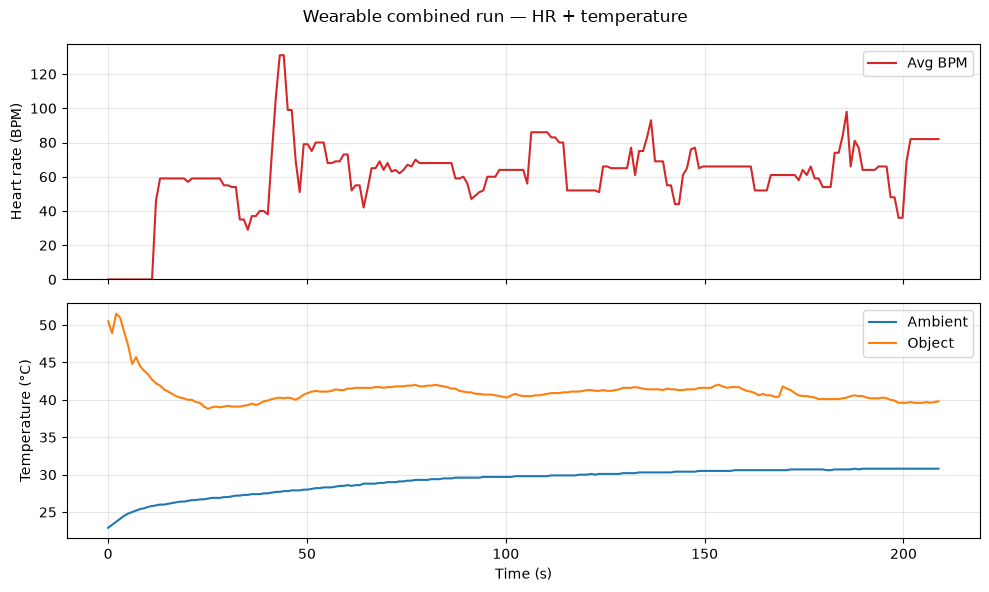

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
fig.suptitle("Wearable combined run — HR + temperature")

ax1.plot(df["t_s"], df["bpm_avg"], color="C3", linewidth=1.5, label="Avg BPM")
ax1.set_ylabel("Heart rate (BPM)")
ax1.set_ylim(bottom=0)
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

ax2.plot(df["t_s"], df["ambient_c"], color="C0", linewidth=1.5, label="Ambient")
ax2.plot(df["t_s"], df["object_c"], color="C1", linewidth=1.5, label="Object")
ax2.set_ylabel("Temperature (°C)")
ax2.set_xlabel("Time (s)")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()  # inline only — no file written